In [ ]:
#Titulo: Aplicación de DIKW para el DataSet de Titanic
#Objetivo: Identtificar las diferentes capas del modelo DIKW en proceso ETL
#Fecha: 21 de mayo

In [12]:
#Importamos librerías
import pandas as pd

In [19]:
pip install matplotlib

In [21]:
pip install seaborn

In [57]:
import matplotlib.pyplot as plt

In [26]:
import seaborn as sns

In [28]:
#cargamos el Dataset
df = pd.read_csv("test.csv")

In [29]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [31]:
df.info(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [32]:
df.describe(include="all")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [33]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [35]:
#Limpieza
#Nombres de columnas en minusculas
df.columns = df.columns.str.strip().str.lower()

In [38]:
df.isnull().sum()

passengerid      0
pclass           0
name             0
sex              0
age             86
sibsp            0
parch            0
ticket           0
fare             1
cabin          327
embarked         0
dtype: int64

In [39]:
#Eliminar una columna
df.drop(columns=["cabin"], inplace=True)

In [40]:
df.columns

Index(['passengerid', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'embarked'],
      dtype='object')

In [41]:
#Rellenamos los datos nulos con la mediana 
df["age"] = df["age"].fillna(df["age"].median())

In [43]:
df.isnull().sum()

passengerid    0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           1
embarked       0
dtype: int64

In [47]:
#Rellenamos el Fare con el valor mas repetido (moda)
df["fare"] = df["fare"].fillna(df["fare"].mode()[0])

In [50]:
df.isnull().sum()

passengerid    0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

In [62]:
#validar datos
df["age"].min()

0.17

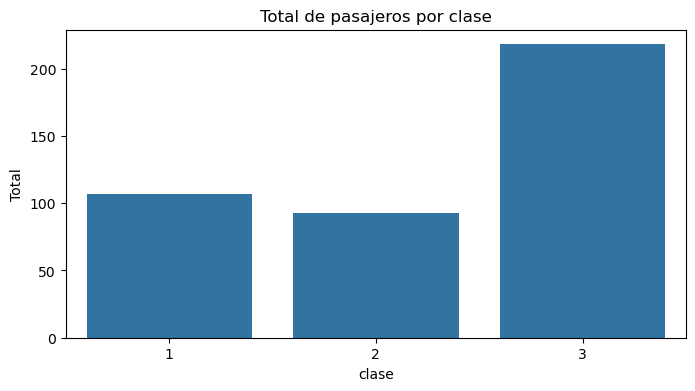

In [60]:
#Graficamos el total de pasajeros por clase
plt.figure(figsize=(8,4)) #Tamaño
sns.countplot(df, x="pclass")
plt.title("Total de pasajeros por clase")
plt.xlabel("clase")
plt.ylabel("Total")
plt.show()

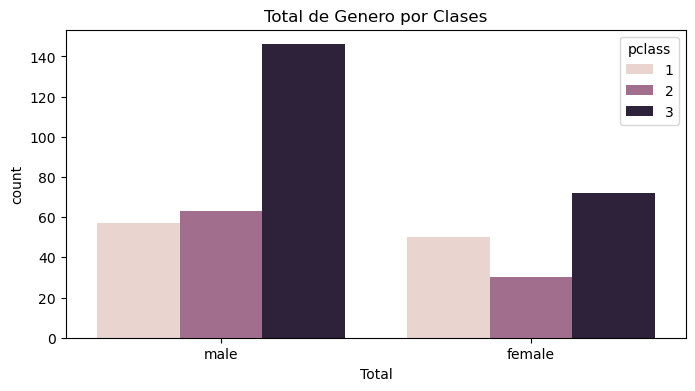

In [61]:
#Graficamos las clases por genero
plt.figure(figsize=(8,4))
sns.countplot(df, x="sex", hue="pclass")
plt.title("Total de Genero por Clases")
plt.xlabel("Total")
plt.show()

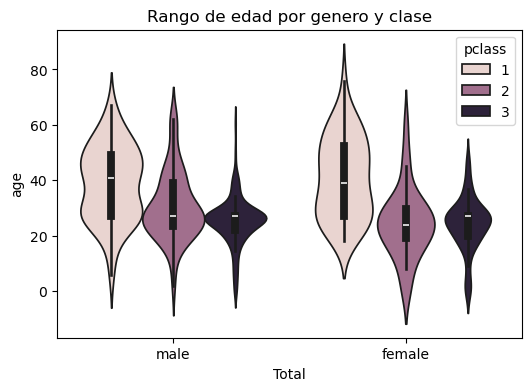

In [63]:
#Mostrar la edad por genero y clase
plt.figure(figsize=(6,4))
sns.violinplot(df, x="sex", y="age", hue="pclass")
plt.title("Rango de edad por genero y clase")
plt.xlabel("Total")
plt.show()

In [65]:
#CONOCIMIENTO
#Los pasajeros de primera clase pagaban tarifas mas altas
df.groupby("pclass")["fare"].mean()

pclass
1    94.280297
2    22.202104
3    12.438074
Name: fare, dtype: float64

In [ ]:
#La distribucion muestra que habia mas
